<a href="https://colab.research.google.com/github/claudio1975/Storm_Events/blob/main/11_Global_Comparison_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global daily prediction per event comparison

## Global Comparison

In [ ]:
#############################################################
# COMPARISON SETUP
#############################################################

from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import drive
from matplotlib.colors import LogNorm, Normalize

drive.mount("/content/drive")

RESULTS_DIR = Path("/content/drive/MyDrive/Storm_Events/global_model_results_v2")
SPLIT_ORDER = ["train", "calibration", "test"]
POINT_METRIC_COLUMNS = ["n", "events", "D2", "RMSE", "MPD"]
GROUP_COL = "EVENT_GROUP"

PREDICTION_TARGETS = ["CASUALTY"]

# which models are compared, in which order, in which colour: one file each in RESULTS_DIR
MODEL_COLORS = {
    "GLM": "#1f4e79",
    "LGBM": "#e07b39",
    "LSTM": "#4c9a2a",
    "TABPFN": "#8e44ad",
    "tabular-transformer": "#ff0000",
}

COMPARISON_METRICS = ["D2", "RMSE", "MPD"]
METRIC_DIRECTION = {"D2": "high = better", "RMSE": "low = better", "MPD": "low = better"}
ALPHA_TARGET = 0.10

payloads = {name: pd.read_pickle(RESULTS_DIR / f"{name}.pkl") for name in MODEL_COLORS}
MODEL_RESULTS = {name: payload["results"] for name, payload in payloads.items()}
MODEL_LABELS = {name: payload["label"] for name, payload in payloads.items()}

Mounted at /content/drive


In [ ]:
#############################################################
# COMPARISON TABLES
#############################################################

def _stack_metrics(results, key, index_names):
    """Stacks one metrics table per target, splits ordered as they occur in
    time: train, calibration, test."""
    df = pd.concat({k: v[key] for k, v in results.items()})
    df.index.names = index_names
    df = df.reset_index()
    df["Split"] = pd.Categorical(df["Split"], categories=SPLIT_ORDER, ordered=True)

    return df.set_index(index_names).sort_index()


def point_metrics_by_target(results):
    """point metrics tables per outcome"""
    return _stack_metrics(results, "metrics", ["Target", "Split"])


def point_metrics_by_event_group(results, group_column=GROUP_COL):
    """point metrics tables per outcome and event group"""
    return _stack_metrics(results, "group_metrics", ["Target", "Split", group_column])


def _add_relative_width(summary):
    """Reads the band width against the level it is measuring.

    MeanWidth is in target units - deaths per month, injuries per day - so it
    cannot be compared across targets, views or event groups. RelWidth can:
    it is MeanWidth over MeanActual."""
    mean_actual = summary["MeanActual"]
    summary["RelWidth"] = summary["MeanWidth"] / mean_actual.where(mean_actual > 0)

    return summary


def collect_point_metrics(model_results=MODEL_RESULTS):
    frames = []
    for model_name, results in model_results.items():
        table = point_metrics_by_target(results).reset_index()
        table["Model"] = model_name
        frames.append(table)

    comparison = pd.concat(frames, ignore_index=True)

    return comparison[["Model", "Target", "Split", *POINT_METRIC_COLUMNS]].sort_values(
        ["Target", "Split", "Model"]
    )


def collect_conformal_by_target(model_results=MODEL_RESULTS, alpha_target=ALPHA_TARGET):
    rows = [
        {
            "Model": model_name,
            "Target": target,
            "Level": level_name,
            "n": len(frame),
            "Coverage": float(frame["covered"].mean()),
            "MeanActual": float(frame["actual"].mean()),
            "MeanWidth": float(frame["width"].mean()),
            "Nominal": 1.0 - alpha_target,
        }
        for model_name, results in model_results.items()
        for target, result in results.items()
        for level_name, frame in (
            ("daily", result["daily_conformal"]),
            ("monthly", result["monthly_conformal"]),
        )
    ]

    return _add_relative_width(pd.DataFrame(rows))[
        ["Model", "Target", "Level", "n", "Coverage",
         "MeanActual", "MeanWidth", "RelWidth", "Nominal"]
    ]

def collect_backtest_metrics(model_results=MODEL_RESULTS, metrics=COMPARISON_METRICS):
    """One row per (model, target, validation year), read from the saved backtest tables.
    Models saved without a backtest are skipped."""
    rows = []
    for model_name, results in model_results.items():
        for target, result in results.items():
            table = result.get("backtest_metrics")
            if table is None:
                continue
            for year, fold in table.drop(index="Mean", errors="ignore").iterrows():
                rows.append({"Model": model_name, "Target": target, "Year": year,
                             **{metric: float(fold[metric]) for metric in metrics}})
    return pd.DataFrame(rows, columns=["Model", "Target", "Year", *metrics])


backtest_comparison = collect_backtest_metrics()
print("models with a backtest:", sorted(backtest_comparison["Model"].unique()))

point_comparison = collect_point_metrics()
conformal_comparison = collect_conformal_by_target()

models with a backtest: ['GLM', 'LGBM', 'LSTM', 'TABPFN', 'tabular-transformer']


In [ ]:
#############################################################
# 1. POINT METRICS: MODEL x TARGET x SPLIT
#############################################################


BACKTEST_PANEL = "backtest mean"


def backtest_mean_table(backtest_table, metrics=COMPARISON_METRICS):
    """Mean of each metric over the backtest validation years, one row per model and target."""
    mean = backtest_table.groupby(["Model", "Target"], as_index=False)[list(metrics)].mean()
    mean["Split"] = BACKTEST_PANEL
    return mean


def plot_metric_comparison(
    metrics_table=None,
    metrics=COMPARISON_METRICS,
    splits=SPLIT_ORDER,
    targets=None,
    model_colors=MODEL_COLORS,
    backtest_table=None,
):
    """One bar per model for each split, plus a last panel with the mean over the backtest years."""
    metrics_table = collect_point_metrics() if metrics_table is None else metrics_table
    backtest_table = collect_backtest_metrics() if backtest_table is None else backtest_table
    targets = list(PREDICTION_TARGETS) if targets is None else list(targets)
    models = list(model_colors)

    table = metrics_table.assign(Split=metrics_table["Split"].astype(str))
    panels = [str(split) for split in splits]
    if not backtest_table.empty:
        table = pd.concat([table, backtest_mean_table(backtest_table, metrics)], ignore_index=True)
        panels.append(BACKTEST_PANEL)

    positions = np.arange(len(targets))
    bar_width = 0.8 / len(models)

    fig, axes = plt.subplots(
        len(metrics),
        len(panels),
        figsize=(5.4 * len(panels), 3.6 * len(metrics)),
        layout="constrained",
        squeeze=False,
    )

    for row, metric in enumerate(metrics):
        for column, panel_name in enumerate(panels):
            ax = axes[row][column]
            panel = table[table["Split"] == panel_name]

            for index, model_name in enumerate(models):
                values = (
                    panel[panel["Model"] == model_name]
                    .set_index("Target")
                    .reindex(targets)[metric]
                    .to_numpy(dtype=float)
                )
                offset = (index - (len(models) - 1) / 2) * bar_width
                bars = ax.bar(
                    positions + offset,
                    values,
                    width=bar_width,
                    color=model_colors[model_name],
                    edgecolor="white",
                    linewidth=0.5,
                    label=model_name if (row == 0 and column == 0) else None,
                )
                ax.bar_label(bars, labels=["n/d" if np.isnan(v) else f"{v:.2f}" for v in values],
                             fontsize=7, padding=2)

            if metric == "D2":
                ax.axhline(0.0, color="grey", linestyle="--", linewidth=1)
            else:
                spread = panel[metric].to_numpy(dtype=float)
                spread = spread[np.isfinite(spread) & (spread > 0)]
                if len(spread) > 0 and spread.max() / spread.min() > 50:
                    ax.set_yscale("log")
                    ax.set_ylim(spread.min() * 0.5, spread.max() * 2.0)

            ax.set_xticks(positions)
            ax.set_xticklabels(targets, rotation=20, ha="right", fontsize=9)
            ax.set_title(f"{metric} — {panel_name} ({METRIC_DIRECTION[metric]})", fontsize=11)
            ax.set_ylabel(metric)

    axes[0][0].legend(fontsize=9, title="Model")
    fig.suptitle("Point metrics by target and split, and mean over the backtest years (2019-2023)",
                 fontsize=14)
    plt.show()




In [ ]:
#############################################################
# 2. CONFORMAL COVERAGE AND RELATIVE WIDTH BY TARGET
#############################################################

def plot_conformal_comparison(
    conformal_table=None,
    levels=("daily",),
    targets=None,
    quantities=("Coverage", "RelWidth"),
    model_colors=MODEL_COLORS,
):
    """Coverage and width per target"""
    conformal_table = collect_conformal_by_target() if conformal_table is None else conformal_table

    targets = list(PREDICTION_TARGETS) if targets is None else list(targets)
    models = list(model_colors)
    columns = [name for name in quantities if name in conformal_table.columns]

    positions = np.arange(len(targets))
    bar_width = 0.8 / len(models)
    target_labels = [name.replace("_", " ").capitalize() for name in targets]
    nominal = (
        float(conformal_table["Nominal"].iloc[0])
        if "Nominal" in conformal_table.columns
        else None
    )

    fig, axes = plt.subplots(
        len(levels),
        len(columns),
        figsize=(7.0 * len(columns), 4.4 * len(levels)),
        layout="constrained",
        squeeze=False,
    )

    for row, level_name in enumerate(levels):
        panel_source = conformal_table[conformal_table["Level"] == level_name]

        for column, quantity in enumerate(columns):
            ax = axes[row][column]

            for index, model_name in enumerate(models):
                values = (
                    panel_source[panel_source["Model"] == model_name]
                    .set_index("Target")
                    .reindex(targets)[quantity]
                    .to_numpy(dtype=float)
                )
                offset = (index - (len(models) - 1) / 2) * bar_width
                bars = ax.bar(
                    positions + offset,
                    values,
                    width=bar_width,
                    color=model_colors[model_name],
                    edgecolor="white",
                    linewidth=0.5,
                    label=model_name if (row == 0 and column == 0) else "_nolegend_",
                )
                ax.bar_label(
                    bars,
                    labels=["" if not np.isfinite(v) else f"{v:.2f}" for v in values],
                    fontsize=8,
                    padding=2,
                )

            if quantity == "Coverage":
                if nominal is not None:
                    ax.axhline(
                        nominal,
                        color="red",
                        linestyle="--",
                        linewidth=1.2,
                        label=f"nominal {nominal:.2f}" if row == 0 else "_nolegend_",
                    )
                ax.set_ylim(0.0, 1.15)
            else:
                spread = panel_source[quantity].to_numpy(dtype=float)
                spread = spread[np.isfinite(spread) & (spread > 0)]

                if len(spread) > 0:
                    if spread.max() / spread.min() > 50:
                        ax.set_yscale("log")
                    else:
                        ax.set_ylim(0.0, spread.max() * 1.20)

            ax.set_xticks(positions)
            ax.set_xticklabels(target_labels, rotation=20, ha="right", fontsize=9)
            ax.set_title(f"{quantity}", fontsize=11)
            ax.set_ylabel(quantity)
            ax.grid(axis="y", alpha=0.25, linewidth=0.6)
            ax.set_axisbelow(True)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside lower center", ncols=len(models) + 1, fontsize=9)
    fig.suptitle("Conformal intervals: coverage and relative width by target", fontsize=14)
    plt.show()




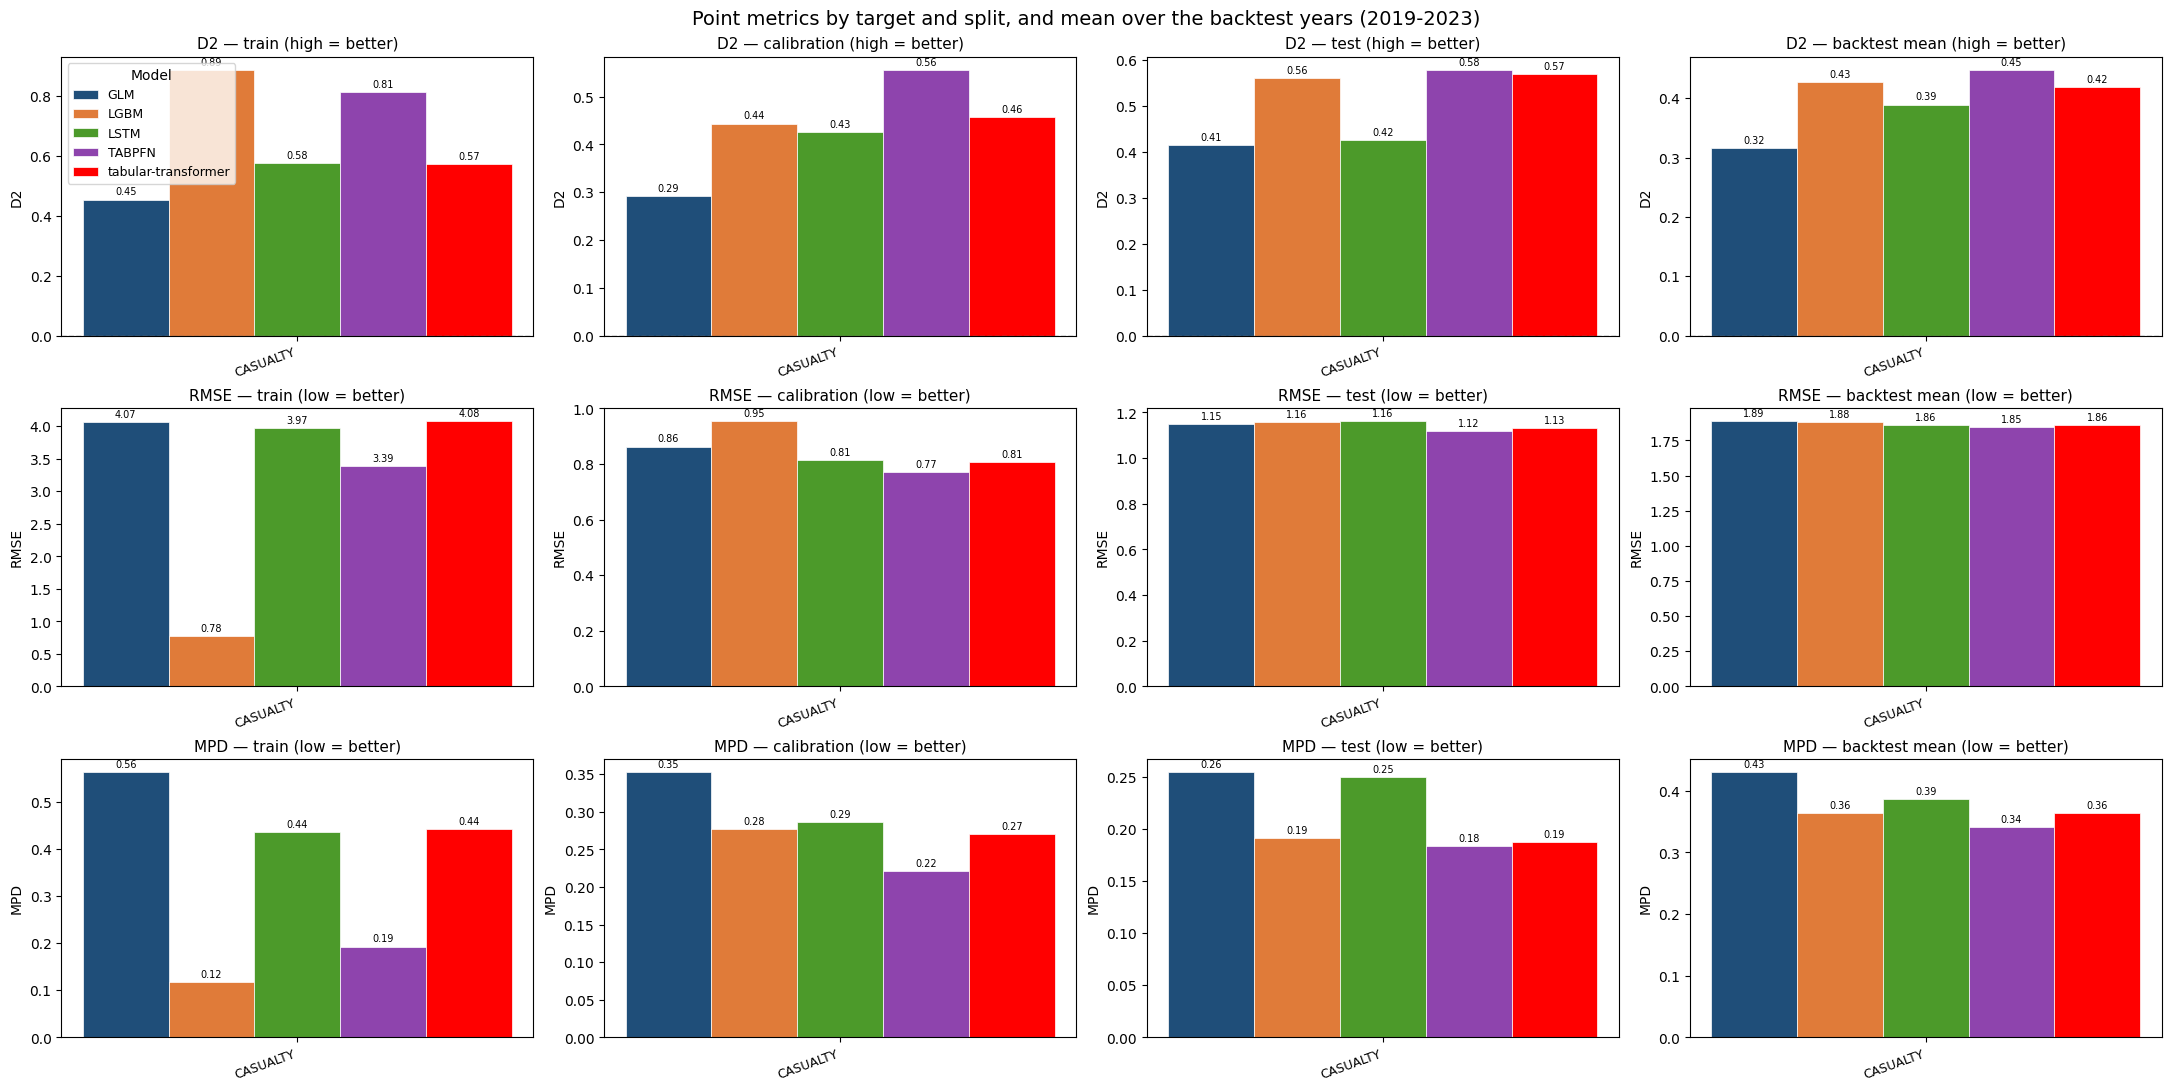

In [ ]:
plot_metric_comparison(point_comparison)


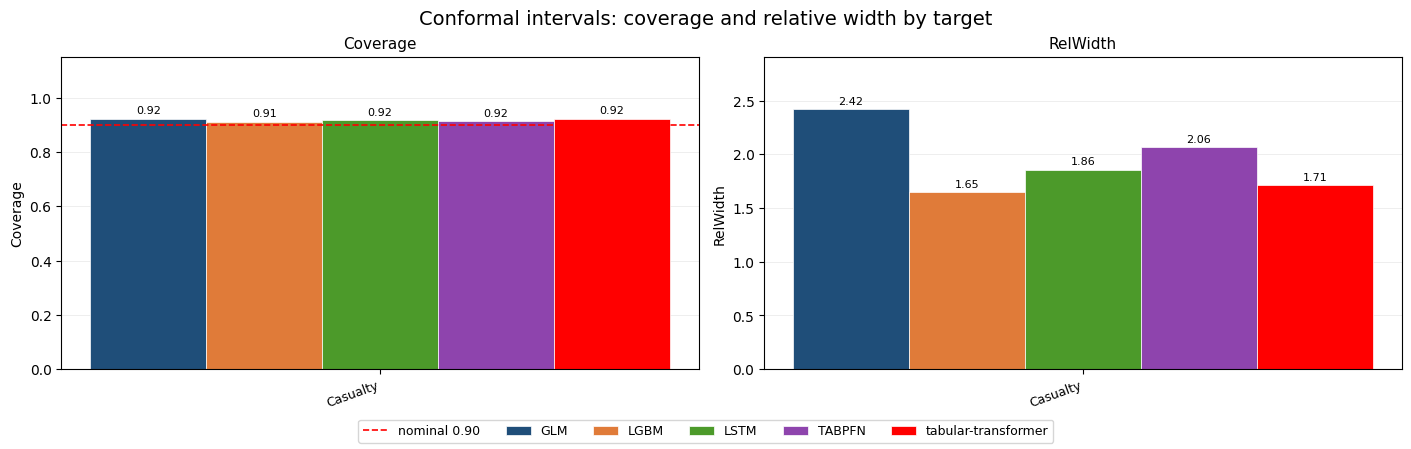

In [ ]:
plot_conformal_comparison(conformal_comparison)

In [ ]:
#############################################################
# INJURIES AND DEATHS FROM THE SPLIT CASUALTY FORECAST
#############################################################

def collect_component_metrics(model_results=MODEL_RESULTS):
    """Injury / death scores of every model, from the constant-share split of its
    CASUALTY forecast. Models saved without the split are skipped."""
    frames = []
    for model_name, results in model_results.items():
        table = results.get("CASUALTY", {}).get("component_metrics")
        if table is None:
            continue
        frame = table.reset_index()
        frame["Model"] = model_name
        frames.append(frame)

    comparison = pd.concat(frames, ignore_index=True)
    # keep the splits every model has (the transformer also has "validation")
    comparison = comparison[comparison["Split"].astype(str).isin(SPLIT_ORDER)].copy()
    comparison["Split"] = pd.Categorical(comparison["Split"].astype(str),
                                         categories=SPLIT_ORDER, ordered=True)
    return comparison


component_comparison = collect_component_metrics()


In [ ]:
print("models with the injury / death split:", sorted(component_comparison["Model"].unique()))
with pd.option_context("display.max_rows", None):
    display(
        component_comparison.set_index(["Target", "Split", "Model"])
        .sort_index()
        .round(4)
    )


models with the injury / death split: ['GLM', 'LGBM', 'LSTM', 'TABPFN', 'tabular-transformer']


n  events      D2  \
Target            Split       Model                                         
DEATHS            train       GLM                  812807    9776  0.3569   
                              LGBM                 812807    9776  0.5851   
                              LSTM                 812807    9776  0.4195   
                              TABPFN               812807    9776  0.5925   
                              tabular-transformer  812807    9776  0.4553   
                  calibration GLM                   37371     510  0.3661   
                              LGBM                  37371     510  0.4289   
                              LSTM                  37371     510  0.4168   
                              TABPFN                37371     510  0.5295   
                              tabular-transformer   37371     510  0.4053   
                  test        GLM                   38495     399  0.5341   
                              LGBM                  38495     399  0.4973   
                              LSTM                  38495     399  0.4190   
                              TABPFN                38495     399  0.4846   
                              tabular-transformer   38495     399  0.5269   
DEATHS_DIRECT     train       GLM                  812807    7724  0.3452   
                              LGBM                 812807    7724  0.5713   
                              LSTM                 812807    7724  0.3908   
                              TABPFN               812807    7724  0.5681   
                              tabular-transformer  812807    7724  0.4319   
                  calibration GLM                   37371     394  0.3112   
                              LGBM                  37371     394  0.3888   
                              LSTM                  37371     394  0.3713   
                              TABPFN                37371     394  0.4779   
                              tabular-transformer   37371     394  0.3577   
                  test        GLM                   38495     271  0.5094   
                              LGBM                  38495     271  0.4370   
                              LSTM                  38495     271  0.3362   
                              TABPFN                38495     271  0.4181   
                              tabular-transformer   38495     271  0.4797   
DEATHS_INDIRECT   train       GLM                  812807    2313  0.2712   
                              LGBM                 812807    2313  0.4261   
                              LSTM                 812807    2313  0.3703   
                              TABPFN               812807    2313  0.4673   
                              tabular-transformer  812807    2313  0.3754   
                  calibration GLM                   37371     168  0.3508   
                              LGBM                  37371     168  0.3763   
                              LSTM                  37371     168  0.3754   
                              TABPFN                37371     168  0.4739   
                              tabular-transformer   37371     168  0.3697   
                  test        GLM                   38495     154  0.4071   
                              LGBM                  38495     154  0.4518   
                              LSTM                  38495     154  0.4406   
                              TABPFN                38495     154  0.4549   
                              tabular-transformer   38495     154  0.4468   
INJURIES          train       GLM                  812807    7204  0.4359   
                              LGBM                 812807    7204  0.8772   
                              LSTM                 812807    7204  0.5619   
                              TABPFN               812807    7204  0.7907   
                              tabular-transformer  812807    7204  0.5472   
                  calibration GLM                   

In [ ]:
display(pd.Series({name: results["CASUALTY"].get("death_share")
                   for name, results in MODEL_RESULTS.items()},
                  name="death share used for the split").round(4))

,death share used for the split
GLM,0.2363
LGBM,0.2363
LSTM,0.2363
TABPFN,0.2363
tabular-transformer,0.2363
